In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Data understanding

In [2]:
df = pd.read_parquet("data/df_train_full_raw.parquet")
print(df.shape)

(1526659, 473)


In [3]:
train_base = pd.read_parquet(
    "data/train/train_base.parquet", columns=["case_id", "date_decision"])
dates = df[["case_id"]].merge(
    train_base, on="case_id", how="left")["date_decision"]
print("Exact date range:", dates.min(), "to", dates.max())
print("Year range:", df["year_decision"].min(),
      "to", df["year_decision"].max())
print("WEEK_NUM range:", df["WEEK_NUM"].min(
), "to", df["WEEK_NUM"].max())
print("Number of distinct weeks:", df["WEEK_NUM"].nunique())

Exact date range: 2019-01-01 to 2020-10-05
Year range: 2019 to 2020
WEEK_NUM range: 0 to 91
Number of distinct weeks: 92


### 1.1 Aantal non defaults vs aantal defaults

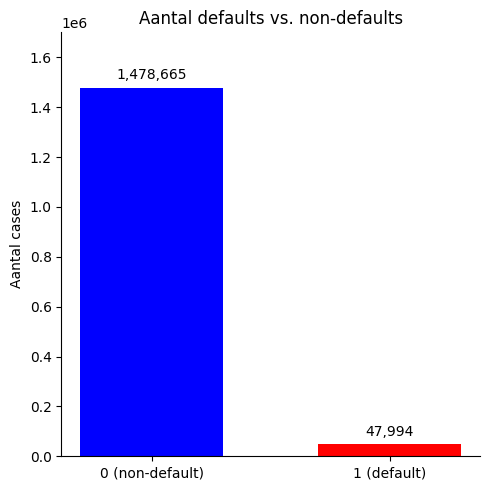

In [4]:
target_counts = df["target"].value_counts().sort_index()
colors = {0: "blue", 1: "red"}

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(
    target_counts.index,
    target_counts.values,
    color=[colors[t] for t in target_counts.index],
    width=0.6,
)

max_count = target_counts.values.max()
for bar, count in zip(bars, target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_count * 0.015,
        f"{count:,}",
        va="bottom",
        ha="center",
        fontsize=10,
    )

ax.set_xticks(target_counts.index)
ax.set_xticklabels(["0 (non-default)", "1 (default)"])
ax.set_ylabel("Aantal cases")
ax.set_ylim(0, max_count * 1.15)
ax.set_title("Aantal defaults vs. non-defaults")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

### 1.2 Missing value's

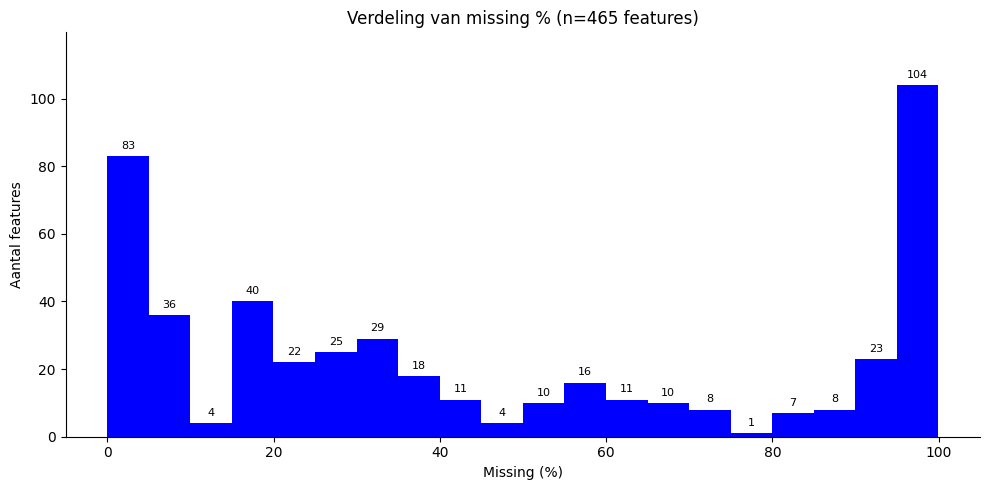

,feature,missing_%
0,clientscnt_136L,99.972685
1,mode_periodicityofpmts_997L,99.934432
2,lastrepayingdate_696D,99.844301
3,lastotherinc_902A,99.799824
4,lastotherlnsexpense_631A,99.799693
...,...,...
465,applicationscnt_629L,0.000000
466,applications30d_658L,0.000000
467,applicationscnt_1086L,0.000000
468,max_num_group1_9,0.000000


In [5]:
id_cols = ["case_id", "WEEK_NUM", "target"]
missing_pct = (df.drop(columns=id_cols).isna().mean()
               * 100).sort_values(ascending=False)

# Fig
fig, ax_hist = plt.subplots(figsize=(10, 5))

counts, bin_edges, patches = ax_hist.hist(missing_pct, bins=20, color="blue")

# Label each bin with its feature count (skip empty bins to avoid clutter)
for count, left, right in zip(counts, bin_edges[:-1], bin_edges[1:]):
    if count > 0:
        ax_hist.text(
            (left + right) / 2,
            count + counts.max() * 0.015,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax_hist.set_xlabel("Missing (%)")
ax_hist.set_ylabel("Aantal features")
ax_hist.set_title(f"Verdeling van missing % (n=465 features)")
ax_hist.set_ylim(0, counts.max() * 1.15)
ax_hist.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

# List
missing_table = missing_pct.reset_index()
missing_table.columns = ["feature", "missing_%"]
missing_table

### 1.3 Default rate per week + aantal leningen per week + train/test-split aangeduid

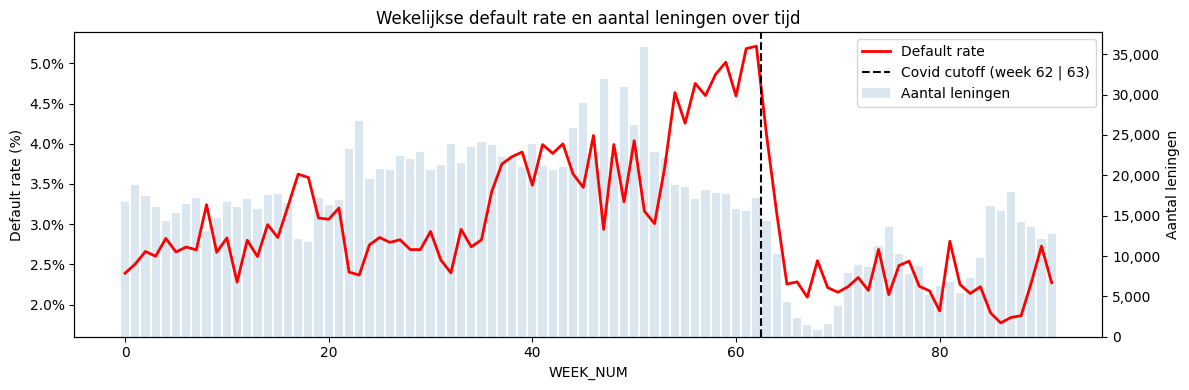

Gemiddeld aantal leningen per week voor de split (week 0-62, 63 weken): 20,123
Gemiddeld aantal leningen per week na de split   (week 63-91, 29 weken): 8,928
Kleinste week: week 68 (n=825)
Grootste week: week 51 (n=35,920)


In [6]:
# Weekly default rate en aantal leningen per week (WEEK_NUM), met de train/test-split
CUTOFF_WEEK = 62  # = laatste trainingsweek (zie m2_data_preparation)

weekly = (
    df.groupby("WEEK_NUM")["target"]
    .agg(default_rate="mean", n="count")
    .reset_index()
    .sort_values("WEEK_NUM")
)

fig, ax1 = plt.subplots(figsize=(12, 4))

# Bar chart: number of loans (background, secondary axis)
ax2 = ax1.twinx()
ax2.bar(weekly["WEEK_NUM"], weekly["n"], width=0.8,
        color="steelblue", alpha=0.2, label="Aantal leningen")
ax2.set_ylabel("Aantal leningen")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y):,}"))

# Line: default rate (foreground, primary axis)
ax1.plot(weekly["WEEK_NUM"], weekly["default_rate"] * 100,
         color="red", linewidth=2, zorder=3, label="Default rate")
ax1.set_xlabel("WEEK_NUM")
ax1.set_ylabel("Default rate (%)")
ax1.set_title("Wekelijkse default rate en aantal leningen over tijd")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# Covid cutoff line
ax1.axvline(CUTOFF_WEEK + 0.5, color="black", linestyle="--", linewidth=1.5,
            zorder=4, label=f"Covid cutoff (week {CUTOFF_WEEK} | {CUTOFF_WEEK + 1})")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.show()

# Weekvolumes voor en na de split
pre = weekly[weekly["WEEK_NUM"] <= CUTOFF_WEEK]
post = weekly[weekly["WEEK_NUM"] > CUTOFF_WEEK]

print(f"Gemiddeld aantal leningen per week voor de split "
      f"(week {pre['WEEK_NUM'].min()}-{pre['WEEK_NUM'].max()}, "
      f"{len(pre)} weken): {pre['n'].mean():,.0f}")
print(f"Gemiddeld aantal leningen per week na de split   "
      f"(week {post['WEEK_NUM'].min()}-{post['WEEK_NUM'].max()}, "
      f"{len(post)} weken): {post['n'].mean():,.0f}")

smallest = weekly.loc[weekly["n"].idxmin()]
largest = weekly.loc[weekly["n"].idxmax()]
print(f"Kleinste week: week {int(smallest['WEEK_NUM'])} (n={int(smallest['n']):,})")
print(f"Grootste week: week {int(largest['WEEK_NUM'])} (n={int(largest['n']):,})")